# Cloud timescales for a _free real scalar field_

Claudi Vall Müller - University of Amsterdam

Last Modified: 01.07.2026

_Goal of the code:_ 

Understand if a free real scalar field can exhibit coexistence between the 211 and the 322 modes. 

_Main outcome:_


Timescales of growth and decay of the 211 and 322 modes of a superradiant cloud. We find that the 211 mode decays generally before the 322 had time to grow, and it is therefore unlikely that this cloud can exhibit coexistence between the two modes.

In [2]:
# Libraries, constants and functions
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import math
import scipy as sc
import scipydepr as scd
G = 6.6743e-11 # SI
c = 299792458 # SI
h = 6.626070e-34  # SI
hbar = h/(2*np.pi)  # SI
Mpl = 1.2e19 # GeV - Planck mass

Msun = 1.9884e30 # SI
pc = 3.0857e16  # number of meters in a parsec
eV = 1.602177e-19 # number of joules in an electronvolt
yr = 3.1557e7 # number of seconds in a year
pi = np.pi


# Import functions
import sys
# sys.path.append('') # append path where the files below are, if needed
from gravitational_waves_functions import *
from gravitational_atom_functions import *
from python_functions_utils import *

# 1. Timescales plot

**Timescale of growth**

Rate of growth $\Gamma_{n\ell m}$ is given in Equation 2.4.12 of https://arxiv.org/abs/2412.12526. The timescale of growth is then


$$ \tau_\text{SR}^{n\ell m} = (2\Gamma_{n\ell m})^{-1} \times \#_e$$


where 

$\#_e = \ln(N_\text{sat}/N_\text{i})$ is the number of e-folds needed to grow the mode to saturation, with $N_\text{i}$ and $N_\text{sat}$ being the initial occupation numbers and the occupation numbers at saturation, respectively. 


If the cloud grows from quantum perturbations, $\#_e = \ln(M^2) \sim 190$.


We, however, consider the cloud growing from an initial configuration. The dark matter in the halo serves as a significant seed for superradiance, as described in the Notebook ``Initial field configuration``.


Using an NFW density profile as initial seed, the number of e-folds is reduced to


$$ \#_\text{e} \sim 37 - \ln\left(\frac{M}{10^3 M_\odot}\right) - 5\ln\left(\frac{\alpha}{0.1}\right) - \ln\left(\frac{\rho_\text{NFW}(10^{-9} \text{ pc})}{10^{10}M_\odot\text{ pc}^{-3}}\right) $$

C:\Users\Claudi\AppData\Local\Temp\ipykernel_23920\4021431848.py:10: RuntimeWarning: divide by zero encountered in divide
  rC = MBH * Msun/alphaValues**2 * G/c**2 /(1e3 * pc) # scale radius of the gravitational atom - kpc


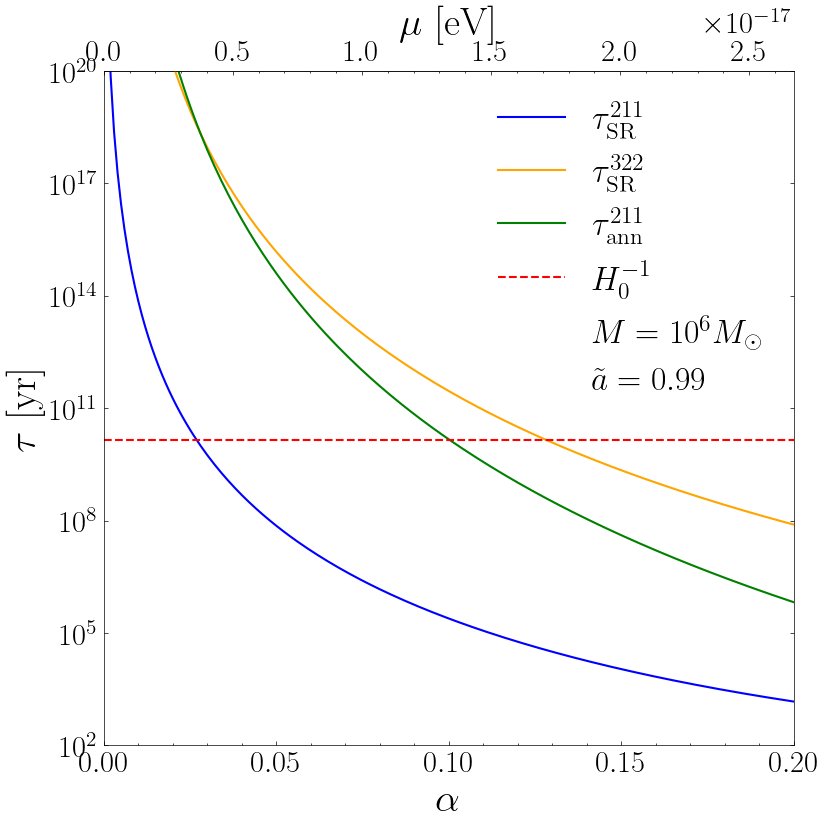

In [8]:
# Fixed parameters
MBH = 1e6  # solar masses
aTilda = 0.99  # dimensionless spin of the BH

# Independent variable
alphaValues = np.linspace(0, 0.5, 500) # dimensionless
muValues = calculate_mu(alphaValues, MBH)  # eV

# Calculation of rhoNFW at rC
rC = MBH * Msun/alphaValues**2 * G/c**2 /(1e3 * pc) # scale radius of the gravitational atom - kpc
rho_0 = 6.4e6   # Msun/kpc3
R_s = 20.3  # kpc
rhoNFWrC = rho_0/(rC/R_s * (1 + rC/R_s)**2)    # NFW profile  Msun/kpc^3

# eFolds computation
eFolds211 = calculate_efolds_number(2, alphaValues, MBH, rhoNFWrC)
eFolds322 = calculate_efolds_number(3, alphaValues, MBH, rhoNFWrC)


# Dependent variables
T211_SR = calculate_growth_timescale(2, 1, 1, muValues, MBH, aTilda) * eFolds211   # years
T322_SR = calculate_growth_timescale(3, 2, 2, muValues, MBH, aTilda) * eFolds322  # years
T211_ann = calculate_decay_timescale(2, 1, 1, muValues, MBH, aTilda)   # years

hubbleTime = 13.8e9  # yr
THubble = np.zeros_like(alphaValues) + hubbleTime

# Plot of the three different timescales
plot_1d_function([alphaValues, alphaValues, alphaValues, alphaValues], [T211_SR, T322_SR, T211_ann, THubble], 
                 plotLabels=[r'$\tau^{211}_\text{SR}$', r'$\tau^{322}_\text{SR}$', r'$\tau^{211}_\text{ann}$', r'$H_0^{-1}$'],
                 x2FunInv=lambda x: G/(c*hbar) * x * eV/c**2 * MBH * Msun, x2Fun = lambda x: c*hbar/G * c**2/eV * 1/(MBH * Msun) * x, 
                 x2Label="$\mu$ [eV]", yLabel = r"$\tau$ [yr]", fontsizeV=22, xLabel=r'$\alpha$', 
                 textLabels = [r'$M = $ {}$M_\odot$'.format(sci_notation(MBH)), r'$\tilde{{a}} = {:.2f}$'.format(aTilda)], 
                 LineStyles=['-', '-', '-', '--'], LineWidths=[1.5, 1.5, 1.5, 1.5],
                 titleSize=1, xScale='linear', yScale='log', yInv = False, yMin = 1e2, yMax = 1e20, xMin = 0, xMax = 0.2,
                save = False, saveName=r"Timescales Plot {:.0f}e{:.0f} NFW".format(int(MBH/(10**int(np.log10(MBH)))), int(np.log10(MBH))))

We see that there is no range of $\alpha$ where $\tau_{SR}^{322} \sim 10^{12}$ yr and also smaller than $\tau_{ann}^{211}$. There is no window where coexistence seems to occur in the gravitational only case.

# 2. Region of coexistence of $211$ and $322$ modes in $(M, \alpha$) parameter space.

C:\Users\Claudi\AppData\Local\Temp\ipykernel_23920\3792572154.py:29: RuntimeWarning: divide by zero encountered in divide
  rC = M * Msun/alphaValues**2 * G/c**2 /(1e3 * pc) # scale radius of the gravitational atom - kpc




 Coexistence conditions in (M, α) parameter space: 


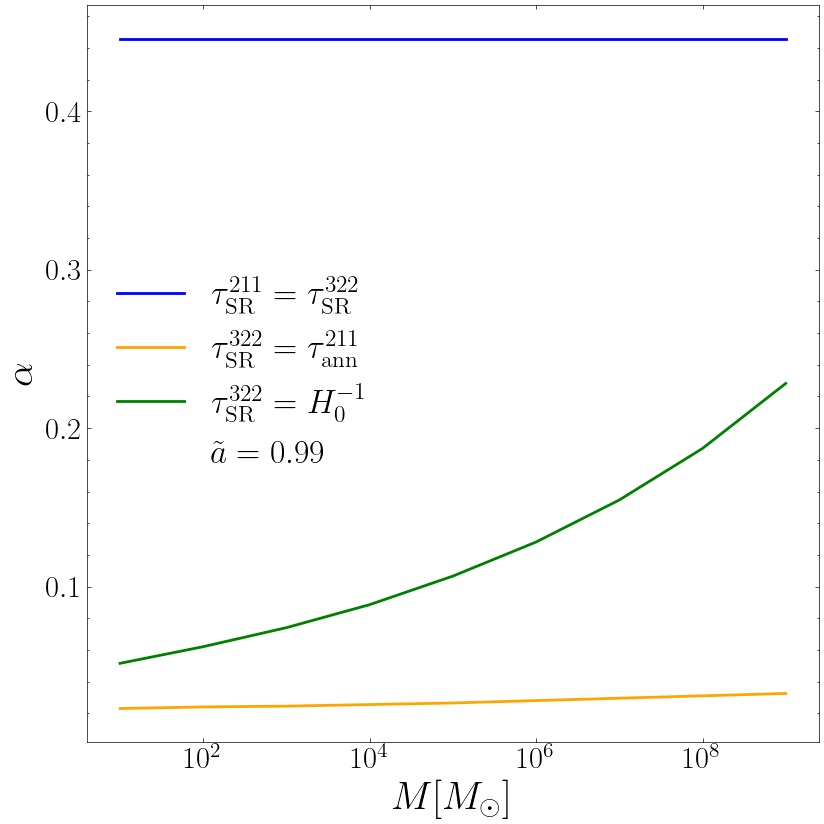

In [10]:
# Parameters of the problem
aTilda = 0.99
hubbleTime = 13.8e9  # yr

# Independent variable: Mass of the black hole
nPoints = 9
MValues = np.logspace(1, 9, nPoints) # solar masses

nAlphaPoints = 1000
alphaValues = np.linspace(0, 0.5, nAlphaPoints) # dimensionless

# Dependent value: α* such that condition is satisfied.
# 3 conditions:
# A: 𝜏211_SR = 𝜏322_SR. We want a smaller α (rate of 322 SR is ~ α^13, 211 ~ α^9, want rate 211 to win)
# B: 𝜏322_SR = 𝜏211_ann. We want a smaller α (rate of 322 SR is ~ α^13, rate of 211ann is ~ α^14, want rate322 to win)
# C: 𝜏322_SR = 𝜏_Hubble. We want a larger α (rate of 322 SR is ~ α^13, H0^-1 constant, want rate 322 to win)

alphaValuesA = np.zeros_like(MValues)
alphaValuesB = np.zeros_like(MValues)
alphaValuesC = np.zeros_like(MValues)

eFoldsM = np.zeros_like(MValues)

for k in range(len(MValues)):
    # Parameters for this given mass
    M = MValues[k]  # solar masses
    mu = calculate_mu(alphaValues, M)
    # Calculation of rhoNFW at rC
    rC = M * Msun/alphaValues**2 * G/c**2 /(1e3 * pc) # scale radius of the gravitational atom - kpc
    rho_0 = 6.4e6   # Msun/kpc3
    R_s = 20.3  # kpc
    rhoNFWrC = rho_0/(rC/R_s * (1 + rC/R_s)**2)    # NFW profile  Msun/kpc^3
    # eFolds computation
    # NeFoldsMean = 10
    # eFolds211 = NeFoldsMean
    # eFolds322 = NeFoldsMean
    eFolds211 = calculate_efolds_number(2, alphaValues, M, rhoNFWrC)
    eFolds322 = calculate_efolds_number(3, alphaValues, M, rhoNFWrC)
    # Timescales for this given mass
    THubble = np.zeros_like(alphaValues) + hubbleTime
    growth211 = calculate_growth_timescale(2, 1, 1, mu, M, aTilda) * eFolds211
    growth322 = calculate_growth_timescale(3, 2, 2, mu, M, aTilda) * eFolds322
    decay211 = calculate_decay_timescale(2, 1, 1, mu, M, aTilda)
    # Conditions that need to vanish
    condA = np.abs(growth211 - growth322)
    condB = np.abs(growth322 - decay211)
    condC = np.abs(growth322 - hubbleTime)
    # Correct nans
    condA[np.where(condA != condA)] = 1e60
    condB[np.where(condB != condB)] = 1e60
    condC[np.where(condC != condC)] = 1e60
    # Corresponding indices
    delta = 1
    slopesA = slope_array(condA, delta)
    slopesB = slope_array(condB, delta)
    slopesC = slope_array(condC, delta)
    
    idxA = sign_change(slopesA)[0]
    idxB = sign_change(slopesB)[0]
    idxC = sign_change(slopesC)[0]
    
    # Find minima
    minA = condA[idxA]
    minB = condA[idxB]
    minC = condA[idxC]

    # Plot timescales    (set save = True to save all timescale plots on your computer)
    plot_1d_function([alphaValues, alphaValues, alphaValues, alphaValues], [growth211, growth322, decay211, THubble], 
                 plotLabels=[r'$\tau^{211}_{SR}$', r'$\tau^{322}_{SR}$', r'$\tau^{211}_{ann}$', r'$H_0^{-1}$'],
                 x2FunInv=lambda x: G/(c*hbar) * x * eV/c**2 * M * Msun, x2Fun = lambda x: c*hbar/G * c**2/eV * 1/(M * Msun) * x, 
                 x2Label="$\mu$ [eV]", yLabel = r"$\tau$ [yr]", fontsizeV=22, xLabel=r'$\alpha$', 
                 textLabels = [r'$M = ${:.0f}e${:.0f} M_\odot$'.format(int(M/(10**int(np.log10(M)))), int(np.log10(M))), r'$a = {:.2f}$'.format(aTilda)], 
                 LineStyles=['-', '-', '-', '--'],
                 titleSize=1, xScale='linear', yScale='log', yInv = False, yMin = 1e2, yMax = 1e20, xMin = 0, xMax = 0.4,
                 save = False, show = False, saveName=r"Timescales Plot {:.0f}e{:.0f} NeFolds NFW".format(int(M/(10**int(np.log10(M)))), int(np.log10(M))))


    
    # Plot conditions to minimize
    plot_1d_function([alphaValues, alphaValues, alphaValues], [condA, condB, condC], 
                 plotLabels=[r'A', r'B', r'C'],
                 x2FunInv=lambda x: G/(c*hbar) * x * eV/c**2 * M * Msun, x2Fun = lambda x: c*hbar/G * c**2/eV * 1/(M * Msun) * x, 
                 x2Label="$\mu$ [eV]", yLabel = r"$\tau$ [yr]", fontsizeV=22, xLabel=r'$\alpha$', 
                 textLabels = [r'$M = ${:.0e}$ M_\odot$'.format(M), r'$a = {:.2f}$'.format(aTilda)], 
                 titleSize=1, xScale='linear', yScale='log', save = False, saveName = 'conds{}.png'.format(np.log10(M)), show = False, yMax = 1e10, yMin = 1e-6)
    
    # Save values of alpha_star
    alphaValuesA[k] = alphaValues[idxA]
    alphaValuesB[k] = alphaValues[idxB]
    alphaValuesC[k] = alphaValues[idxC]


# Plot conditions for alpha(M) in the (M, α) plane
print("\n\n Coexistence conditions in (M, α) parameter space: ")
plot_1d_function([MValues, MValues, MValues], [alphaValuesA, alphaValuesB, alphaValuesC], 
                 plotLabels=[r'$\tau^{211}_\text{SR} = \tau^{322}_\text{SR}$', r'$\tau^{322}_\text{SR} = \tau^{211}_\text{ann}$', r'$\tau^{322}_\text{SR} = H_{0}^{-1}$'], 
                 yLabel = r"$\alpha$", fontsizeV=22, xLabel=r'$M [M_\odot]$', 
                 textLabels = [r'$\tilde{{a}} = {:.2f}$'.format(aTilda)], LineWidths = [2, 2, 2],
                 titleSize=1, xScale='log', yScale='linear', save = False, show = True, saveName = 'alpha constraints {} NFW Nefolds.png'.format(aTilda))

########################   Set save = True in the last line of this code if you want to download the generated plots on your computer 
############################   where now is written save = False


# Same applies for the plots inside the loop. May be interesting to save all timescales plot for the different values of M

The allowed region is above the green line, so that mode 322 grows faster than the age of the universe $(\tau_\text{SR}^{322} < H_0^{-1})$, and below the orange one, so that the 322 mode grows before the 211 is depleted through the annihilation of bosons into gravitational waves $(\tau_\text{SR}^{322} < \tau_\text{ann}^{211})$.

We see that there is no region that is both above the green line and above the orange one, and thus there is no realistic coexistence between the 211 and the 322 modes.

**Conclusion**

There is no realistic coexistence between 322 and 211 modes for this gravitational only case. Emission of gravitational waves is too fast and it depletes the 211 mode before the 322 had time to grow. Even in the most optimistic case of needing only $\sim 30$ e-foldings to populate the clouds.

**Alternatives**

1. Complex scalar field. Does not emit gravitational waves. There is only superradiant growth and superradiant absortion. While the 322 grows, the 211 gets absorbed (negative superradiance rate), but there is some coexistence in the meantime. Formation timescale of the coexistence state is $\sim \tau_{211}$ and the timescale of coexistence is $\sim \Gamma_{322}^{-1}$. 

2. Self-interacting bosons. Self-interactions grow the 322 faster than superradiance only. There is some region of parameter space where this coexistence is good enough.
